In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/KaggleDataset/ISICDataset.zip" -d "/content/data/"
print("Dataset extracted")

Dataset extracted


Using device: cpu
Full dataframe shape: (401059, 8)
Train: 298560 | Val: 53629 | Test: 48870
Meta dim: 10
Metadata columns: ['age_approx', 'sex', 'sex_missing', 'clin_size_long_diam_mm', 'site_anterior torso', 'site_head/neck', 'site_lower extremity', 'site_posterior torso', 'site_unknown', 'site_upper extremity']
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 148MB/s]


Loaded raw state_dict
Model loaded successfully.
ISIC ID: ISIC_0082829
True label: 1
Predicted probability: 0.8248471617698669


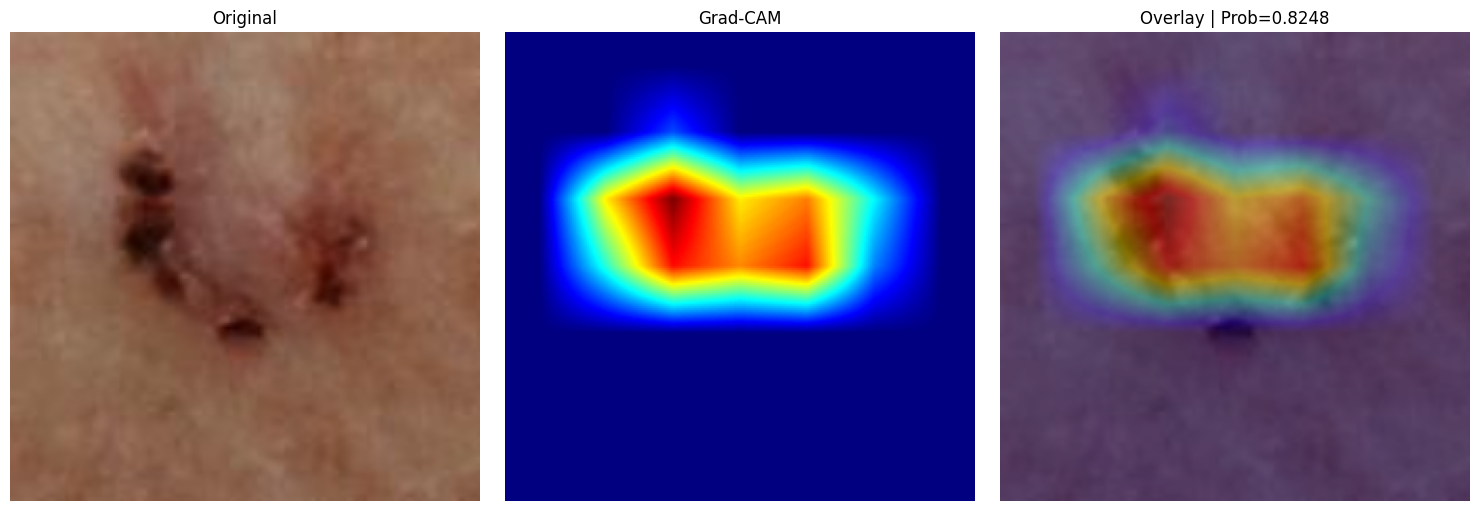

Saved Grad-CAM outputs to: /content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/efficientnet_b2_fusion_Large/gradcam_outputs
Saved ISIC_0082829 | true=1 | prob=0.8248
Saved ISIC_0211092 | true=1 | prob=0.1611
Saved ISIC_0293670 | true=1 | prob=0.6673
Saved ISIC_0321944 | true=1 | prob=0.2484
Saved ISIC_0332355 | true=1 | prob=0.2318
Saved ISIC_0467830 | true=1 | prob=0.6647
Saved ISIC_0664135 | true=1 | prob=0.8649
Saved ISIC_0699524 | true=1 | prob=0.6829
Saved ISIC_0793445 | true=1 | prob=0.8419
Saved ISIC_0814829 | true=1 | prob=0.2666
Saved ISIC_0015845 | true=0 | prob=0.8438
Saved ISIC_0051812 | true=0 | prob=0.3573
Saved ISIC_0052004 | true=0 | prob=0.0101
Saved ISIC_0052355 | true=0 | prob=0.3060
Saved ISIC_0070972 | true=0 | prob=0.3262
Saved ISIC_0073316 | true=0 | prob=0.4876
Saved ISIC_0073522 | true=0 | prob=0.4562
Saved ISIC_0073672 | true=0 | prob=0.0183
Saved ISIC_0076213 | true=0 | prob=0.1537
Saved ISIC_0076244 | true=0 | prob=0.2055


In [ ]:
import os
import io
import cv2
import h5py
import json
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import torch.nn as nn
from torchvision import models
from torchvision.models import MobileNet_V3_Small_Weights, MobileNet_V3_Large_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

INDEX_PATH = "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/final_dataset_index.csv"
TRAIN_HDF5 = "/content/data/train-image.hdf5"

BEST_MODEL_PATH = "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/efficientnet_b2_fusion_Large/mobilenetv3_fusion_best (1).pth"

SAVE_DIR = "/content/drive/MyDrive/2413-Sanket-Naik-Dissertation-2025-26/Implimentations/efficientnet_b2_fusion_Large"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = 224
BACKBONE_NAME = "mobilenetv3_large"

# MODEL DEFINITION
class MobileNetV3Fusion(nn.Module):
    def __init__(self, meta_dim, backbone_name="mobilenetv3_small", dropout=0.3, meta_hidden=64, fusion_hidden=256):
        super().__init__()

        if backbone_name == "mobilenetv3_small":
            backbone = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
            in_features = backbone.classifier[0].in_features
        elif backbone_name == "mobilenetv3_large":
            backbone = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
            in_features = backbone.classifier[0].in_features
        else:
            raise ValueError("backbone_name must be 'mobilenetv3_small' or 'mobilenetv3_large'")

        backbone.classifier = nn.Identity()
        self.backbone = backbone

        self.image_proj = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.Hardswish(),
            nn.Dropout(dropout),
        )

        self.meta_net = nn.Sequential(
            nn.Linear(meta_dim, meta_hidden),
            nn.BatchNorm1d(meta_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(meta_hidden, 64),
            nn.ReLU(inplace=True),
        )

        self.gate = nn.Sequential(
            nn.Linear(256 + 64, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.Sigmoid(),
        )

        self.meta_to_img = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, fusion_hidden),
            nn.BatchNorm1d(fusion_hidden),
            nn.Hardswish(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )

    def forward(self, image, meta):
        img_feat = self.backbone(image)
        img_feat = self.image_proj(img_feat)

        meta_feat = self.meta_net(meta)
        meta_as_img = self.meta_to_img(meta_feat)

        gate = self.gate(torch.cat([img_feat, meta_feat], dim=1))
        gated_img = gate * img_feat + (1.0 - gate) * meta_as_img

        fused = torch.cat([gated_img, meta_feat], dim=1)
        logits = self.classifier(fused).squeeze(1)
        return logits

# METADATA PREPROCESSOR

class MetadataPreprocessor:
    def __init__(self):
        self.age_median = None
        self.age_min = None
        self.age_max = None
        self.size_median = None
        self.size_q99 = None
        self.site_cols = None

    def fit(self, df):
        df = df.copy()

        self.age_median = float(df["age_approx"].median())
        age_filled = df["age_approx"].fillna(self.age_median)
        self.age_min = float(age_filled.min())
        self.age_max = float(age_filled.max())

        if "clin_size_long_diam_mm" in df.columns:
            size_series = df["clin_size_long_diam_mm"]
            self.size_median = float(size_series.median()) if size_series.notna().any() else 0.0
            self.size_q99 = float(size_series.quantile(0.99)) if size_series.notna().any() else 1.0
        else:
            self.size_median = 0.0
            self.size_q99 = 1.0

        site_series = df["anatom_site_general"].fillna("unknown").astype(str)
        self.site_cols = sorted(site_series.unique().tolist())
        return self

    def transform(self, df):
        df = df.copy()

        df["age_approx"] = df["age_approx"].fillna(self.age_median)
        df["age_approx"] = (df["age_approx"] - self.age_min) / (self.age_max - self.age_min + 1e-8)

        df["sex_missing"] = df["sex"].isna().astype(np.float32)
        df["sex"] = df["sex"].map({"male": 0.0, "female": 1.0}).fillna(0.5)

        if "clin_size_long_diam_mm" in df.columns:
            df["clin_size_long_diam_mm"] = df["clin_size_long_diam_mm"].fillna(self.size_median)
            df["clin_size_long_diam_mm"] = df["clin_size_long_diam_mm"].clip(0, self.size_q99) / (self.size_q99 + 1e-8)
        else:
            df["clin_size_long_diam_mm"] = 0.0

        site = df["anatom_site_general"].fillna("unknown").astype(str)
        for col in self.site_cols:
            df[f"site_{col}"] = (site == col).astype(np.float32)

        meta_cols = ["age_approx", "sex", "sex_missing", "clin_size_long_diam_mm"] + [f"site_{c}" for c in self.site_cols]

        for c in meta_cols:
            if c not in df.columns:
                df[c] = 0.0

        return df, meta_cols

# LOAD INDEX + PREPROCESS
assert os.path.exists(INDEX_PATH), f"Missing index file: {INDEX_PATH}"
assert os.path.exists(TRAIN_HDF5), f"Missing HDF5 file: {TRAIN_HDF5}"
assert os.path.exists(BEST_MODEL_PATH), f"Missing model file: {BEST_MODEL_PATH}"

df = pd.read_csv(INDEX_PATH)
print("Full dataframe shape:", df.shape)

train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

preprocessor = MetadataPreprocessor().fit(train_df)
train_df, meta_cols = preprocessor.transform(train_df)
val_df, _ = preprocessor.transform(val_df)
test_df, _ = preprocessor.transform(test_df)

print("Meta dim:", len(meta_cols))
print("Metadata columns:", meta_cols)

# LOAD MODEL
model = MobileNetV3Fusion(
    meta_dim=len(meta_cols),
    backbone_name=BACKBONE_NAME,
    dropout=0.3,
    meta_hidden=64,
    fusion_hidden=256,
).to(DEVICE)

state = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

# handles both pure state_dict and checkpoint dict
if isinstance(state, dict) and "model_state" in state:
    model.load_state_dict(state["model_state"])
    print("Loaded checkpoint['model_state']")
else:
    model.load_state_dict(state)
    print("Loaded raw state_dict")

model.eval()
print("Model loaded successfully.")

# IMAGE TRANSFORM
cam_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# GRAD-CAM CLASS
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def generate(self, image_tensor, meta_tensor):
        self.model.zero_grad()

        logits = self.model(image_tensor, meta_tensor)
        score = logits[0]
        score.backward(retain_graph=True)

        grads = self.gradients[0]   # [C, H, W]
        acts = self.activations[0]  # [C, H, W]

        weights = grads.mean(dim=(1, 2), keepdim=True)
        cam = (weights * acts).sum(dim=0)
        cam = torch.relu(cam)

        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        prob = torch.sigmoid(score).item()
        return cam, prob

# TARGET LAYER
target_layer = model.backbone.features[-1]

# target_layer = model.backbone.features[-2]

grad_cam = GradCAM(model, target_layer)

# HELPERS
def load_sample_from_hdf5(row, hdf5_path, meta_cols):
    with h5py.File(hdf5_path, "r") as h5:
        raw = h5[row["isic_id"]][()]
        image = np.array(Image.open(io.BytesIO(raw)).convert("RGB"))

    transformed = cam_tf(image=image)
    image_tensor = transformed["image"].unsqueeze(0).to(DEVICE)

    meta_tensor = torch.tensor(
        row[meta_cols].values.astype(np.float32),
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    return image, image_tensor, meta_tensor

def overlay_heatmap_on_image(image_rgb, cam, alpha=0.4):
    image_resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image_resized, 1 - alpha, heatmap, alpha, 0)
    return image_resized, heatmap, overlay

def predict_one(image_tensor, meta_tensor):
    with torch.no_grad():
        logits = model(image_tensor, meta_tensor)
        prob = torch.sigmoid(logits)[0].item()
    return prob

malignant_cases = test_df[test_df["target"] == 1].reset_index(drop=True)
benign_cases = test_df[test_df["target"] == 0].reset_index(drop=True)

row = malignant_cases.iloc[0]

original_image, image_tensor, meta_tensor = load_sample_from_hdf5(row, TRAIN_HDF5, meta_cols)

pred_prob = predict_one(image_tensor, meta_tensor)
cam, cam_prob = grad_cam.generate(image_tensor, meta_tensor)
orig, heatmap, overlay = overlay_heatmap_on_image(original_image, cam)

print("ISIC ID:", row["isic_id"])
print("True label:", int(row["target"]))
print("Predicted probability:", pred_prob)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay | Prob={pred_prob:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

# SAVE OUTPUTS
OUTPUT_CAM_DIR = os.path.join(SAVE_DIR, "gradcam_outputs")
os.makedirs(OUTPUT_CAM_DIR, exist_ok=True)

Image.fromarray(orig).save(os.path.join(OUTPUT_CAM_DIR, f"{row['isic_id']}_original.png"))
Image.fromarray(heatmap).save(os.path.join(OUTPUT_CAM_DIR, f"{row['isic_id']}_heatmap.png"))
Image.fromarray(overlay).save(os.path.join(OUTPUT_CAM_DIR, f"{row['isic_id']}_overlay.png"))

print("Saved Grad-CAM outputs to:", OUTPUT_CAM_DIR)

def run_cam_batch(df_subset, label_name, n_samples=5):
    subset = df_subset.reset_index(drop=True)
    out_dir = os.path.join(SAVE_DIR, "gradcam_outputs", label_name)
    os.makedirs(out_dir, exist_ok=True)

    for i in range(min(n_samples, len(subset))):
        row = subset.iloc[i]
        original_image, image_tensor, meta_tensor = load_sample_from_hdf5(row, TRAIN_HDF5, meta_cols)
        pred_prob = predict_one(image_tensor, meta_tensor)
        cam, _ = grad_cam.generate(image_tensor, meta_tensor)
        orig, heatmap, overlay = overlay_heatmap_on_image(original_image, cam)

        Image.fromarray(orig).save(os.path.join(out_dir, f"{row['isic_id']}_original.png"))
        Image.fromarray(heatmap).save(os.path.join(out_dir, f"{row['isic_id']}_heatmap.png"))
        Image.fromarray(overlay).save(os.path.join(out_dir, f"{row['isic_id']}_overlay.png"))

        print(f"Saved {row['isic_id']} | true={int(row['target'])} | prob={pred_prob:.4f}")

# Example usage:
run_cam_batch(test_df[test_df["target"] == 1], "malignant", n_samples=10)
run_cam_batch(test_df[test_df["target"] == 0], "benign", n_samples=10)